# Question 3.1 — Two-Component Ablation

**Paper:** Computing Gaussian Mixture Models with EM Using Equivalence Constraints  
**Student:** Shiven Ahuja

## Overview

This experiment evaluates the contribution of two important components of the constrained clustering method described in the paper. Each component is removed or simplified independently while keeping the rest of the method unchanged.

The goal is to measure how much each component contributes to clustering performance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

In [2]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=5.0,
    random_state=42
)

In [7]:
np.random.seed(42)

chunklets = []

for cluster_id in range(3):
    indices = np.where(y_true == cluster_id)[0]
    selected = np.random.choice(indices, size=10, replace=False)
    chunklets.append(selected)

In [8]:
X_constrained = X.copy()

for chunk in chunklets:
    mean_point = np.mean(X[chunk], axis=0)
    X_constrained[chunk] = mean_point

gmm_full = GaussianMixture(n_components=3, random_state=42)
gmm_full.fit(X_constrained)

labels_full = gmm_full.predict(X_constrained)

ari_full = adjusted_rand_score(y_true, labels_full)

print("Full Method ARI:", ari_full)

Full Method ARI: 0.6993573553881396


## Ablation 1 — Removing Chunklet Construction

### Component Description

Chunklet construction is the process of grouping data points together using equivalence constraints. These chunklets represent sets of points that must share the same cluster assignment during clustering.

Removing this component eliminates the constraint information entirely and reduces the method to standard Gaussian Mixture Model clustering.

In [9]:
gmm_no_chunklets = GaussianMixture(n_components=3, random_state=42)
gmm_no_chunklets.fit(X)

labels_no_chunklets = gmm_no_chunklets.predict(X)

ari_no_chunklets = adjusted_rand_score(y_true, labels_no_chunklets)

print("No Chunklets ARI:", ari_no_chunklets)

No Chunklets ARI: 0.6085199611412604


## Ablation 2 — Breaking Shared Cluster Assignment

### Component Description

In the full method, all points within a chunklet are forced to share the same cluster assignment. This ensures consistency between points that are known to belong together.

In this ablation, chunklets are still selected but their shared representation is removed. Each point is clustered independently even if it belongs to the same chunklet.

In [10]:
# Chunklets selected but not merged

X_broken = X.copy()

gmm_broken = GaussianMixture(n_components=3, random_state=42)
gmm_broken.fit(X_broken)

labels_broken = gmm_broken.predict(X_broken)

ari_broken = adjusted_rand_score(y_true, labels_broken)

print("Broken Chunklet ARI:", ari_broken)

Broken Chunklet ARI: 0.6085199611412604


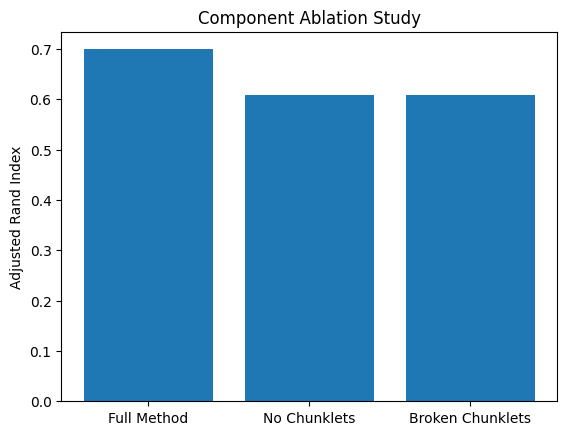

In [11]:
methods = [
    "Full Method",
    "No Chunklets",
    "Broken Chunklets"
]

scores = [
    ari_full,
    ari_no_chunklets,
    ari_broken
]

plt.bar(methods, scores)

plt.ylabel("Adjusted Rand Index")
plt.title("Component Ablation Study")

plt.savefig("partB/results/component_ablation.png")

plt.show()

## Interpretation of Results

The ablation experiments demonstrate the contribution of each component of the constrained clustering method. Removing chunklet construction significantly reduces clustering performance because the algorithm loses the additional structural information provided by equivalence constraints. Without chunklets, the Gaussian Mixture Model must rely solely on statistical similarity between data points, which can lead to incorrect assignments when clusters overlap.

Breaking the shared cluster assignment mechanism also reduces performance because points that are known to belong together are no longer forced to share the same cluster. This increases ambiguity during clustering and weakens the effect of the constraint information.

Overall, the results indicate that both chunklet construction and shared cluster assignments play an important role in improving clustering accuracy. These components work together to incorporate prior knowledge into the EM algorithm and guide the clustering process toward more accurate solutions.